Dataset Shape: (10000, 13)

Column Names:
['job_id', 'job_title', 'company', 'location', 'company_size', 'industry', 'experience_required', 'education', 'posted_date', 'skills', 'salary', 'applications', 'views']

First 5 rows:
       job_id           job_title    company  location company_size  \
0  JOB_000000  Frontend Developer  Cognizant    Mumbai        Small   
1  JOB_000001    Senior Developer       Uber    Jaipur          Mid   
2  JOB_000002  Analytics Engineer  Accenture      Pune        Small   
3  JOB_000003     DevOps Engineer  Startup_A  Gurugram          Mid   
4  JOB_000004  Frontend Developer        HCL   Kolkata          Mid   

     industry  experience_required education                 posted_date  \
0  Healthcare                    1    Master  2025-10-29 11:29:42.237054   
1   Logistics                    5    Master  2026-07-26 11:29:42.237071   
2   Education                    1    Master  2026-09-09 11:29:42.237075   
3   Logistics                   13  Bache

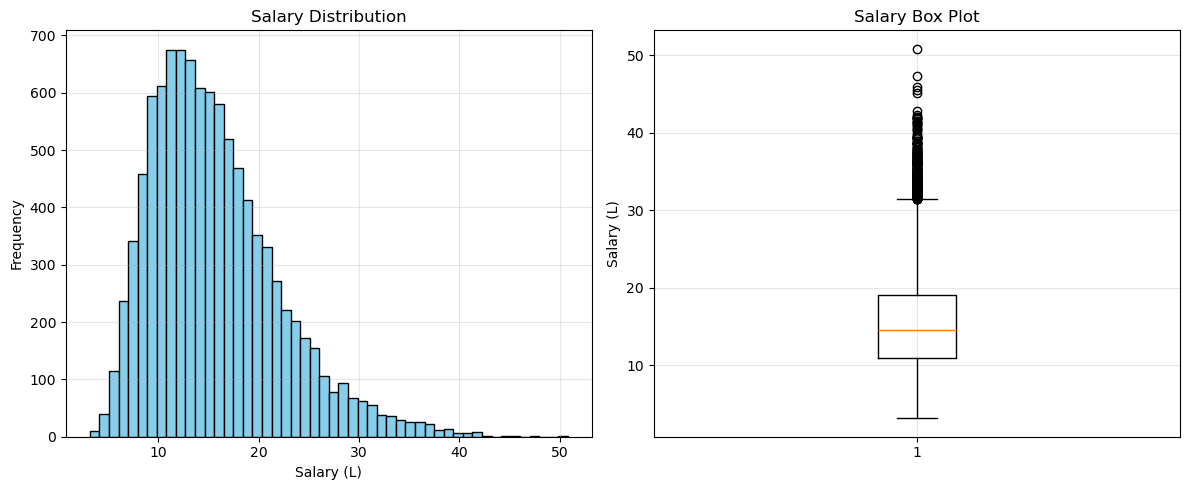

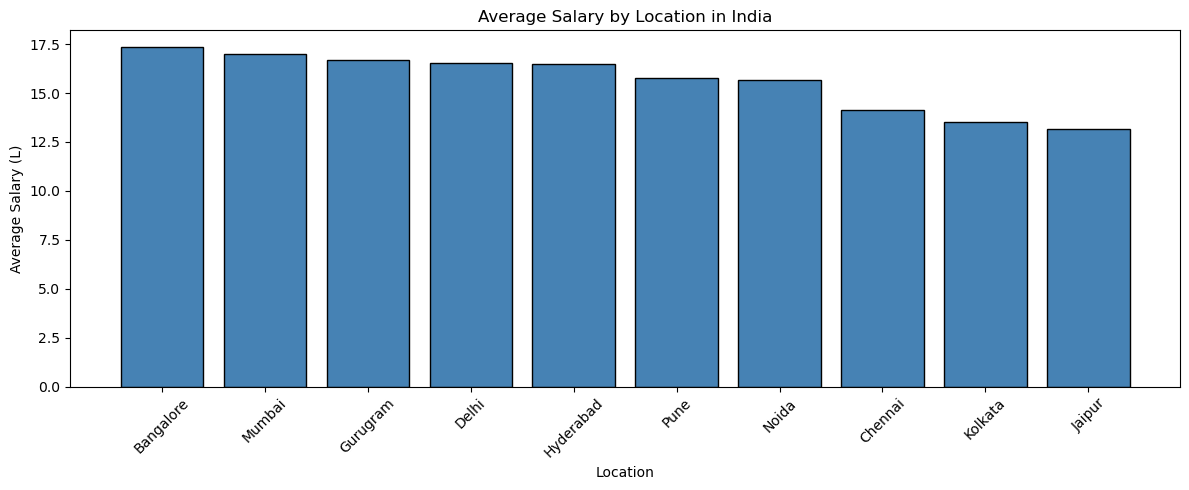

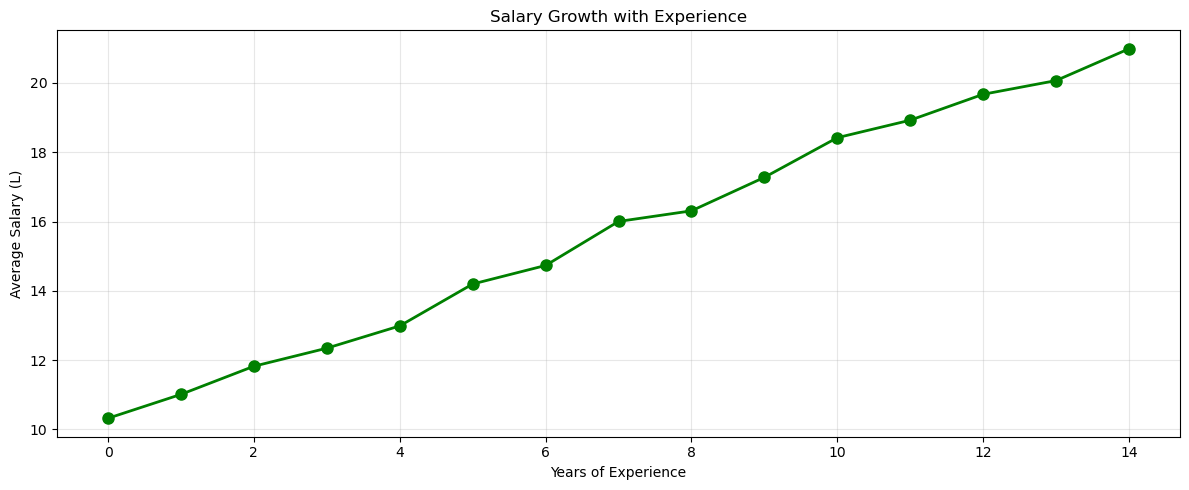

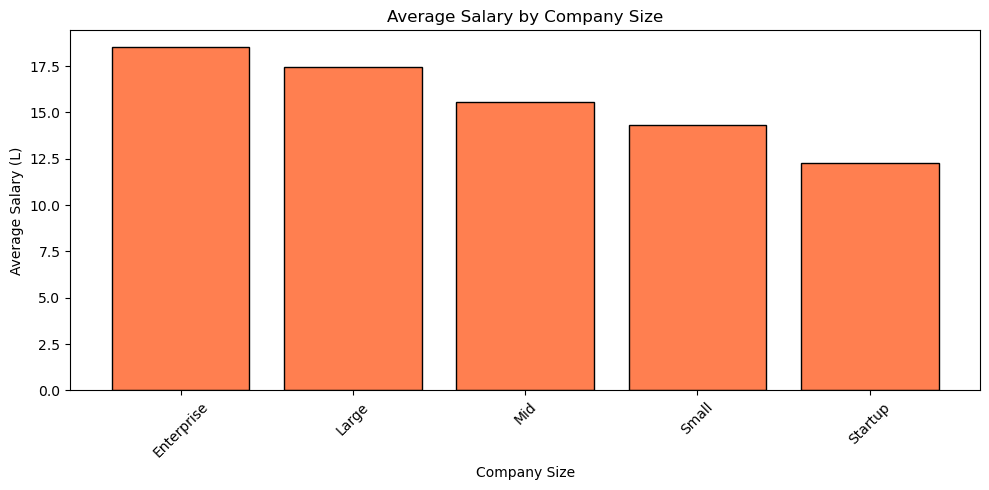


✅ EDA Complete!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data/raw/jobs_raw.csv')

# 1. Dataset Overview
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# 2. Salary Statistics
print("\n" + "="*60)
print("SALARY ANALYSIS")
print("="*60)
print(f"Mean Salary: ₹{df['salary'].mean():.2f}L")
print(f"Median Salary: ₹{df['salary'].median():.2f}L")
print(f"Std Dev: ₹{df['salary'].std():.2f}L")
print(f"Min: ₹{df['salary'].min():.2f}L")
print(f"Max: ₹{df['salary'].max():.2f}L")

# 3. Salary by Location
print("\n" + "="*60)
print("SALARY BY LOCATION")
print("="*60)
location_stats = df.groupby('location')['salary'].agg(['count', 'mean', 'median'])
print(location_stats.sort_values('mean', ascending=False))

# 4. Salary by Job Title
print("\n" + "="*60)
print("SALARY BY JOB TITLE")
print("="*60)
job_stats = df.groupby('job_title')['salary'].agg(['count', 'mean'])
print(job_stats.sort_values('mean', ascending=False).head(10))

# 5. Salary by Experience
print("\n" + "="*60)
print("SALARY BY EXPERIENCE")
print("="*60)
exp_stats = df.groupby('experience_required')['salary'].agg(['count', 'mean'])
print(exp_stats)

# 6. Salary by Company Size
print("\n" + "="*60)
print("SALARY BY COMPANY SIZE")
print("="*60)
size_stats = df.groupby('company_size')['salary'].mean().sort_values(ascending=False)
print(size_stats)

# 7. Visualization 1: Salary Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['salary'], bins=50, edgecolor='black', color='skyblue')
plt.xlabel('Salary (L)')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([df['salary']], vert=True)
plt.ylabel('Salary (L)')
plt.title('Salary Box Plot')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Visualization 2: Salary by Location
plt.figure(figsize=(12, 5))
location_salary = df.groupby('location')['salary'].mean().sort_values(ascending=False)
plt.bar(location_salary.index, location_salary.values, color='steelblue', edgecolor='black')
plt.xlabel('Location')
plt.ylabel('Average Salary (L)')
plt.title('Average Salary by Location in India')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9. Visualization 3: Experience vs Salary
plt.figure(figsize=(12, 5))
exp_salary = df.groupby('experience_required')['salary'].mean()
plt.plot(exp_salary.index, exp_salary.values, marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel('Years of Experience')
plt.ylabel('Average Salary (L)')
plt.title('Salary Growth with Experience')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Visualization 4: Company Size vs Salary
plt.figure(figsize=(10, 5))
size_salary = df.groupby('company_size')['salary'].mean().sort_values(ascending=False)
plt.bar(size_salary.index, size_salary.values, color='coral', edgecolor='black')
plt.xlabel('Company Size')
plt.ylabel('Average Salary (L)')
plt.title('Average Salary by Company Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ EDA Complete!")